# Dimensionality reduction on epochs

In [1]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --Machine learning and statistics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from scipy import stats
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.utils import resample

# Image processing
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
import cv2

# Get my functions
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//2_fit_models/'
os.chdir(functions_path)
from preprocessing_functions import idxs_from_files
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial/4_analyses/5_clustering_analyses/'
os.chdir(functions_path)
# from clustering_functions import calculate_entropy
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette
from one.api import ONE
one = ONE(mode='remote')

In [8]:
data_path = prefix + 'representation_learning_variability/paper-individuality/fig1_segmentation/'
filename = 'all_sequences_26-03-2026'
all_sequences = pd.read_parquet(data_path+filename)


## Get sequences per epoch

In [27]:
all_sequences['session'] = all_sequences['sample'].str[:36]
design_df = all_sequences.pivot(index=['sample', 'trial_type', 'mouse_name', 'session'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
var_names = design_df.keys()[-4:]

In [28]:
# Maybe problematic sessions
prob_sessions = ['87ad026d-5b95-4022-8d59-c260870d830f', 
                 '3e6a97d3-3991-49e2-b346-6948cb4580fb', 
                 '5b49aca6-a6f4-4075-931a-617ad64c219c', 
                 'ee212778-3903-4f5b-ac4b-a72f22debf03',
                 '51e53aff-1d5d-4182-a684-aba783d50ae5',
                 '5bcafa14-71cb-42fa-8265-ce5cda1b89e0']

# Maybe problematic sessions
prob_sessions = [
'30af8629-7b96-45b7-8778-374720ddbc5e',
'90e524a2-aa63-47ce-b5b8-1b1941a1223a',
'a8a8af78-16de-4841-ab07-fde4b5281a03',
'49368f16-de69-4647-9a7a-761e94517821',
'a71175be-d1fd-47a3-aa93-b830ea3634a1',
'0deb75fb-9088-42d9-b744-012fb8fc4afb',
'02fbb6da-3034-47d6-a61b-7d06c796a830',
'7f6b86f9-879a-4ea2-8531-294a221af5d0',
'8c33abef-3d3e-4d42-9f27-445e9def08f9',
'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
'510b1a50-825d-44ce-86f6-9678f5396e02']


In [29]:
design_df = design_df.loc[~design_df['session'].isin(prob_sessions)].reset_index()

In [30]:
len(design_df['session'].unique())

308

In [9]:
epoch_sequences = np.vstack(all_sequences['binned_sequence'])  # Transpose to get the right shape

use_mat = pd.DataFrame(epoch_sequences)
use_mat['epoch'] = pd.factorize(all_sequences['broader_label'])[0]
named_labels = all_sequences['broader_label']

## Separate states per variable (one-hot encoding)

In [7]:
use_sequences = epoch_sequences

use_states = int(max(np.unique(epoch_sequences)))+1
timesteps = np.shape(use_sequences)[1]
binarized = np.zeros((np.shape(use_sequences)[0], timesteps*use_states))

for t in range(timesteps):
    label_binarizer = LabelBinarizer()
    label_binarizer.fit(range(use_states))
    encoded_arr = label_binarizer.transform(use_sequences[:, t])
    binarized[:, t*use_states:(t+1)*use_states] = encoded_arr

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/externals/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


ValueError: Input contains NaN.

## Alternative 9 dimensional encoding

In [31]:
epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
sequences_choice = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape
# use_sequences = sequences_choice[~np.isnan(sequences_choice).any(axis=1)]
use_sequences = sequences_choice

In [32]:
# --- PARAMETERS ---
n_paw_states = 8
n_features_per_step = 10  # 8 Paw + 1 Whisk + 1 Lick
n_trials = use_sequences.shape[0]
timesteps = use_sequences.shape[1]

binarized = np.zeros((n_trials, timesteps * n_features_per_step))
for t in range(timesteps):
    # current_step_codes 
    current_vals = use_sequences[:, t]
    # Identify NaN values
    nan_mask = np.isnan(current_vals)
    # Only process non-NaN values
    valid_mask = ~nan_mask
    labels_0idx = current_vals[valid_mask].astype(int)
    start_col = t * n_features_per_step
    
    if len(labels_0idx) > 0:  # Only if there are valid values
        # 1. Fill Paw States (Cols 0-7) for valid trials only
        paw_indices = labels_0idx % 8
        valid_row_idx = np.arange(n_trials)[valid_mask]
        binarized[valid_row_idx, start_col + paw_indices] = 1
        # 2. Fill Whisking (Col 8) for valid trials only
        binarized[valid_mask, start_col + 8] = ((labels_0idx // 8) % 2).astype(int)
        # 3. Fill Licking (Col 9) for valid trials only
        binarized[valid_mask, start_col + 9] = (labels_0idx // 16).astype(int)
    
    # Set all features for this timestep to NaN where original data was NaN
    if np.any(nan_mask):
        feature_cols = slice(start_col, start_col + n_features_per_step)
        binarized[nan_mask, feature_cols] = np.nan

# Delete Paw State 8 (index 7) for every timestep to avoid collinearity
cols_to_delete = [t * 10 + 7 for t in range(timesteps)]
binarized_9d = np.delete(binarized, cols_to_delete, axis=1)

# If Paw State 2 is at index 1 (0-indexed)
cols_to_delete = [t * 10 + 1 for t in range(timesteps)]
binarized_9d_ref2 = np.delete(binarized, cols_to_delete, axis=1)

In [36]:
np.unique(binarized_9d)

array([ 0.,  1., nan])

In [45]:
binarized_9d_ref2 = binarized_9d_ref2[~np.isnan(binarized_9d).any(axis=1)]
final_matrix = binarized_9d_ref2.copy()

In [49]:
np.shape(binarized_9d_ref2)

(185613, 360)

([<matplotlib.axis.XTick at 0x7fdf31e872e0>,
 [Text(0, 0, '0'), Text(160, 0, '160'), Text(320, 0, '320')])

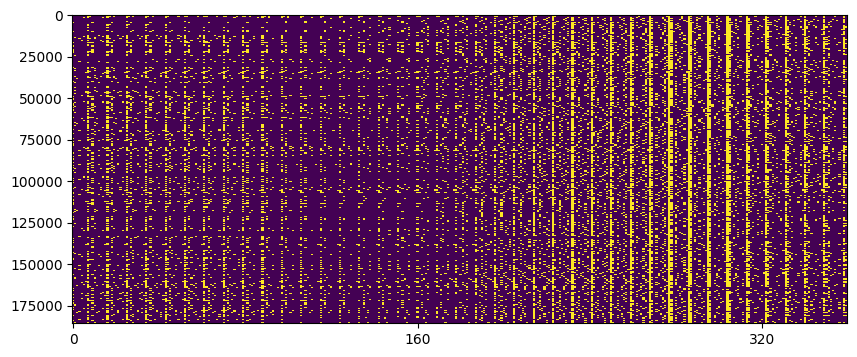

In [46]:
plt.figure(figsize=(10, 4))
plt.imshow(np.array(final_matrix), aspect='auto', cmap='viridis', interpolation='none')
plt.xticks(np.arange(0, np.shape(final_matrix)[1], 160), np.arange(0, np.shape(final_matrix)[1], 160))

# PCA

In [85]:
n_components = 300
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
standardized_X = scaler.fit_transform(final_matrix)
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(final_matrix)

Text(0.5, 1.0, 'Explained Variance by PCA')

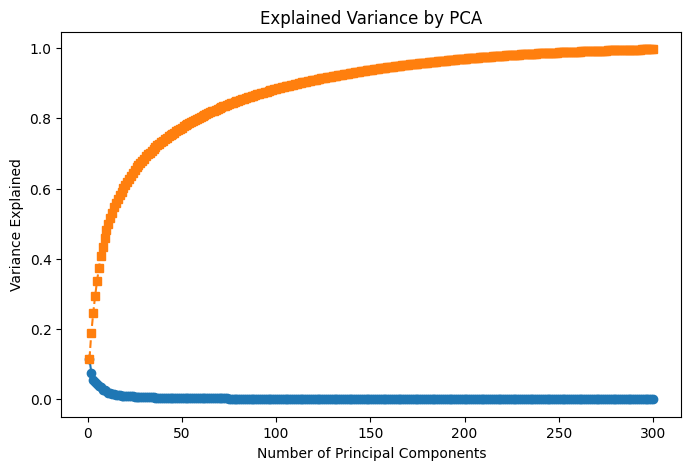

In [86]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

# UMAP

In [66]:
ori_X = X_pca.copy()
# ori_X = final_matrix.copy()

In [67]:
reducer = umap.UMAP(random_state= 42, n_components=2)
# reducer = umap.UMAP(n_components=2)

embedding = reducer.fit_transform(ori_X)
# embedding = reducer.fit_transform(X_pca)
embedding.shape

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


(185613, 2)

In [68]:
from skimage.filters import threshold_otsu
from skimage.filters import gaussian
from skimage.segmentation import find_boundaries
from skimage.morphology import disk


In [69]:
def plot_kde(X_embedded, kernel, xmin, xmax, ymin, ymax, res):
    X, Y = np.mgrid[xmin:xmax:res, ymin:ymax:res]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kernel(positions).T, X.shape)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r,
            extent=[xmin, xmax, ymin, ymax], aspect='auto')
    ax.plot(X_embedded[:, 0], X_embedded[:, 1], 'k.', 
            markersize=.1, alpha=.1)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

    plt.show()

    return Z

def points_to_pixels(points, xmin, xmax, ymin, ymax, nx, ny):
    px = ((points[:, 0] - xmin) / (xmax - xmin) * (nx - 1)).astype(int)
    py = ((points[:, 1] - ymin) / (ymax - ymin) * (ny - 1)).astype(int)

    px = np.clip(px, 0, nx - 1)
    py = np.clip(py, 0, ny - 1)

    return px, py

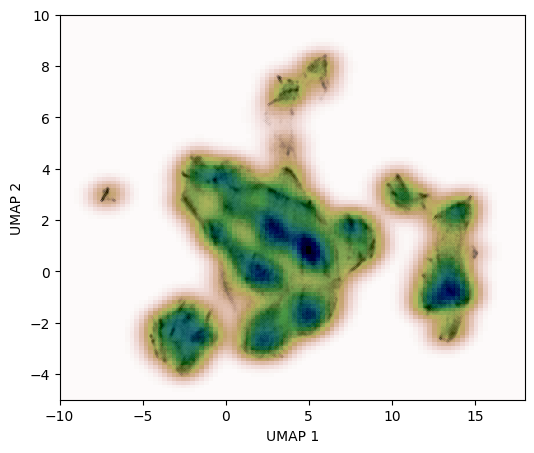

In [72]:
""" Perform Gaussian kde """
values = embedding.T.copy()
kernel = stats.gaussian_kde(values)

xmin = -10
xmax = 18
ymin=-5
ymax=10
Z = plot_kde(embedding, kernel, xmin, xmax, ymin, ymax, res=100j)

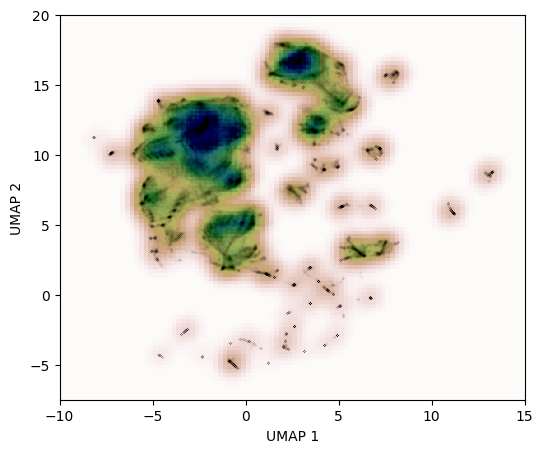

In [61]:
""" Perform Gaussian kde """
values = embedding.T.copy()
kernel = stats.gaussian_kde(values)

xmin = -10
xmax = 15
ymin=-7.5
ymax=20
Z = plot_kde(embedding, kernel, xmin, xmax, ymin, ymax, res=100j)

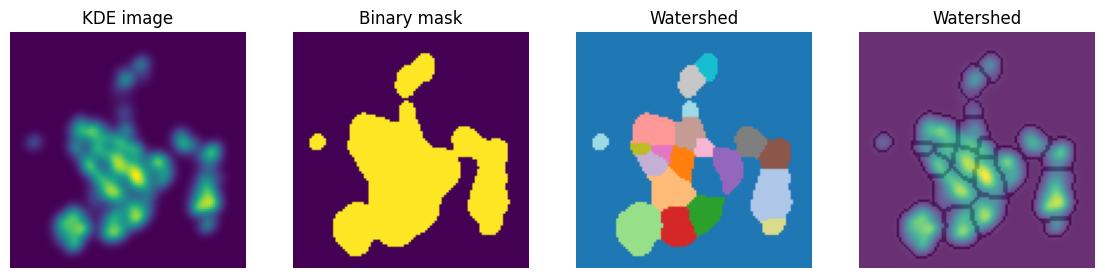

In [83]:
image = Z.copy()
# image = gaussian(image, sigma=.5)

binary = image > np.percentile(image, 70)
binary = ndi.binary_fill_holes(binary)

coords = peak_local_max(
    image,
    footprint=disk(1),
    min_distance=5,
    labels=binary)
markers = np.zeros(image.shape, dtype=int)
markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)

labels = watershed(-image, markers, mask=binary)

boundaries = find_boundaries(labels, mode="outer")

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
ax[0].imshow(np.rot90(Z))
ax[0].set_title("KDE image")
ax[1].imshow(np.rot90(binary))
ax[1].set_title("Binary mask")
ax[2].imshow(np.rot90(labels), cmap="tab20")
ax[2].set_title("Watershed")
ax[3].imshow(np.rot90(image))
ax[3].imshow(np.rot90(boundaries), cmap="Reds", alpha=0.2)
ax[3].set_title("Watershed")
for a in ax:
    a.axis("off")
plt.show()

In [78]:
epoch_number = pd.factorize(named_labels)[0]
cmap = plt.get_cmap("tab10")
clusters = np.unique(epoch_number)
color_dict = {
    k: cmap(k % cmap.N)   # exact tab20 color
    for k in clusters}
scatter_colors = np.array([color_dict[k] for k in epoch_number])
# plt.scatter(
#     embedding[:, 0],
#     embedding[:, 1],
#     color=scatter_colors, #c=point_labels,
#     cmap="tab20",
#     s=2, alpha=.1)
# plt.imshow(np.rot90(boundaries), cmap=plt.cm.gist_earth_r,
#         extent=[xmin, xmax, ymin, ymax], aspect='auto')
# plt.axis("off")
# plt.show()

ValueError: 'c' argument has 808722 elements, which is inconsistent with 'x' and 'y' with size 185613.

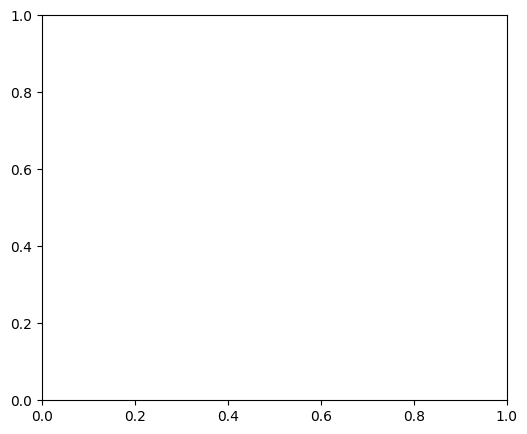

In [79]:
fig, ax = plt.subplots(figsize=(6, 5))
xmin = -15
xmax = -5
ymin=5
ymax=10
ax.scatter(embedding[:, 0], embedding[:, 1], color=scatter_colors, alpha=.5, s=.1) #'k.',
ax.set_xlim([xmin, xmax])
ax.set_ylim([ymin, ymax])
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

plt.show()

In [67]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
np.save(data_path+'epoch_umap_no_standardiz', embedding)
# embedding.to_parquet(data_path+'epoch_umap_no_standardiz',compression='gzip') 